<a href="https://colab.research.google.com/github/UMIDATA77/CCFD-with-ML-algorithms/blob/main/Task_1_umid_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install pybullet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 13.9 MB/s eta 0:00:00


In [3]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import time

print("PyBullet imported successfully.")

PyBullet imported successfully.


In [4]:
import os

PROJECT_DIR = "/content/PyBullet_Task1"
URDF_DIR = os.path.join(PROJECT_DIR, "urdf")

os.makedirs(URDF_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("URDF directory:", URDF_DIR)

Project directory: /content/PyBullet_Task1
URDF directory: /content/PyBullet_Task1/urdf


In [5]:
URDF_DIR = "/content/urdf_models"

os.makedirs(URDF_DIR, exist_ok=True)

print("URDF directory created:")
print(URDF_DIR)

URDF directory created:
/content/urdf_models


In [6]:
robot_urdf = r'''<?xml version="1.0"?>
<robot name="two_wheel_robot">

    <!-- Main chassis -->
    <link name="base_link">
        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="5.0"/>
            <inertia ixx="0.2" ixy="0" ixz="0"
                     iyy="0.3" iyz="0" izz="0.3"/>
        </inertial>

        <visual>
            <origin xyz="0 0 0"/>
            <geometry>
                <box size="0.8 0.5 0.2"/>
            </geometry>
            <material name="blue">
                <color rgba="0.1 0.3 0.8 1"/>
            </material>
        </visual>

        <collision>
            <origin xyz="0 0 0"/>
            <geometry>
                <box size="0.8 0.5 0.2"/>
            </geometry>
        </collision>
    </link>

    <!-- Left wheel -->
    <link name="left_wheel">
        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="0.5"/>
            <inertia ixx="0.01" ixy="0" ixz="0"
                     iyy="0.01" iyz="0" izz="0.01"/>
        </inertial>

        <visual>
            <origin xyz="0 0 0" rpy="0 1.5708 0"/>
            <geometry>
                <cylinder radius="0.15" length="0.08"/>
            </geometry>
            <material name="black">
                <color rgba="0.05 0.05 0.05 1"/>
            </material>
        </visual>

        <collision>
            <origin xyz="0 0 0" rpy="0 1.5708 0"/>
            <geometry>
                <cylinder radius="0.15" length="0.08"/>
            </geometry>
        </collision>
    </link>

    <!-- Right wheel -->
    <link name="right_wheel">
        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="0.5"/>
            <inertia ixx="0.01" ixy="0" ixz="0"
                     iyy="0.01" iyz="0" izz="0.01"/>
        </inertial>

        <visual>
            <origin xyz="0 0 0" rpy="0 1.5708 0"/>
            <geometry>
                <cylinder radius="0.15" length="0.08"/>
            </geometry>
            <material name="black">
                <color rgba="0.05 0.05 0.05 1"/>
            </material>
        </visual>

        <collision>
            <origin xyz="0 0 0" rpy="0 1.5708 0"/>
            <geometry>
                <cylinder radius="0.15" length="0.08"/>
            </geometry>
        </collision>
    </link>

    <!-- Left wheel joint -->
    <joint name="left_wheel_joint"
          type="continuous">
        <parent link="base_link"/>
        <child link="left_wheel"/>
        <origin xyz="-0.42 0 0"/>
        <axis xyz="1 0 0"/>
    </joint>

    <!-- Right wheel joint -->
    <joint name="right_wheel_joint"
          type="continuous">
        <parent link="base_link"/>
        <child link="right_wheel"/>
        <origin xyz="0.42 0 0"/>
        <axis xyz="1 0 0"/>
    </joint>

</robot>
'''

with open(f"{URDF_DIR}/robot.urdf", "w") as f:
    f.write(robot_urdf)

print("robot.urdf created.")

robot.urdf created.


In [7]:
wall_urdf = r'''<?xml version="1.0"?>
<robot name="wall">

    <link name="wall_link">

        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="20"/>
            <inertia ixx="1" ixy="0" ixz="0"
                     iyy="1" iyz="0" izz="1"/>
        </inertial>

        <visual>
            <geometry>
                <box size="4.5 0.2 1.0"/>
            </geometry>
            <material name="wall_material">
                <color rgba="0.55 0.55 0.60 1"/>
            </material>
        </visual>

        <collision>
            <geometry>
                <box size="4.5 0.2 1.0"/>
            </geometry>
        </collision>

    </link>
</robot>
'''

with open(f"{URDF_DIR}/wall.urdf", "w") as f:
    f.write(wall_urdf)

print("wall.urdf created.")

wall.urdf created.


In [8]:
pillar_urdf = r'''<?xml version="1.0"?>
<robot name="pillar">

    <link name="pillar_link">

        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="10"/>
            <inertia ixx="0.5" ixy="0" ixz="0"
                     iyy="0.5" iyz="0" izz="0.5"/>
        </inertial>

        <visual>
            <geometry>
                <cylinder radius="0.3" length="1.2"/>
            </geometry>
            <material name="pillar_material">
                <color rgba="0.8 0.45 0.1 1"/>
            </material>
        </visual>

        <collision>
            <geometry>
                <cylinder radius="0.3" length="1.2"/>
            </geometry>
        </collision>

    </link>
</robot>
'''

with open(f"{URDF_DIR}/pillar.urdf", "w") as f:
    f.write(pillar_urdf)

print("pillar.urdf created.")

pillar.urdf created.


In [9]:
table_urdf = r'''<?xml version="1.0"?>
<robot name="table">

    <link name="table_link">

        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="15"/>
            <inertia ixx="1" ixy="0" ixz="0"
                     iyy="1" iyz="0" izz="1"/>
        </inertial>

        <visual>
            <geometry>
                <box size="1.2 0.8 0.8"/>
            </geometry>
            <material name="table_material">
                <color rgba="0.45 0.25 0.12 1"/>
            </material>
        </visual>

        <collision>
            <geometry>
                <box size="1.2 0.8 0.8"/>
            </geometry>
        </collision>

    </link>
</robot>
'''

with open(f"{URDF_DIR}/table.urdf", "w") as f:
    f.write(table_urdf)

print("table.urdf created.")

table.urdf created.


In [10]:
box_urdf = r'''<?xml version="1.0"?>
<robot name="box_object">

    <link name="box_link">

        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="5"/>
            <inertia ixx="0.1" ixy="0" ixz="0"
                     iyy="0.1" iyz="0" izz="0.1"/>
        </inertial>

        <visual>
            <geometry>
                <box size="0.7 0.7 0.5"/>
            </geometry>
            <material name="box_material">
                <color rgba="0.2 0.65 0.35 1"/>
            </material>
        </visual>

        <collision>
            <geometry>
                <box size="0.7 0.7 0.5"/>
            </geometry>
        </collision>

    </link>
</robot>
'''

with open(f"{URDF_DIR}/box.urdf", "w") as f:
    f.write(box_urdf)

print("box.urdf created.")

box.urdf created.


In [11]:
obstacle_urdf = r'''<?xml version="1.0"?>
<robot name="obstacle">

    <link name="obstacle_link">

        <inertial>
            <origin xyz="0 0 0"/>
            <mass value="6"/>
            <inertia ixx="0.1" ixy="0" ixz="0"
                     iyy="0.1" iyz="0" izz="0.1"/>
        </inertial>

        <visual>
            <geometry>
                <box size="0.9 0.4 0.6"/>
            </geometry>
            <material name="obstacle_material">
                <color rgba="0.75 0.15 0.15 1"/>
            </material>
        </visual>

        <collision>
            <geometry>
                <box size="0.9 0.4 0.6"/>
            </geometry>
        </collision>

    </link>
</robot>
'''

with open(f"{URDF_DIR}/obstacle.urdf", "w") as f:
    f.write(obstacle_urdf)

print("obstacle.urdf created.")

obstacle.urdf created.


In [12]:
physicsClient = p.connect(p.DIRECT)

p.setAdditionalSearchPath(pybullet_data.getDataPath())

p.setGravity(0, 0, -9.81)

print("PyBullet connected using DIRECT mode.")

PyBullet connected using DIRECT mode.


In [13]:
plane_id = p.loadURDF("plane.urdf")

print("Ground plane loaded.")

Ground plane loaded.


In [14]:
robot_id = p.loadURDF(
    f"{URDF_DIR}/robot.urdf",
    basePosition=[0, 0, 0.25],
    useFixedBase=False
)

print("Two-wheel robot loaded.")

Two-wheel robot loaded.


In [15]:
objects = []

# Wall 1
wall1 = p.loadURDF(
    f"{URDF_DIR}/wall.urdf",
    basePosition=[0, 3.0, 0.5]
)
objects.append(wall1)

# Wall 2
wall2 = p.loadURDF(
    f"{URDF_DIR}/wall.urdf",
    basePosition=[0, -3.0, 0.5],
    baseOrientation=p.getQuaternionFromEuler([0, 0, math.pi])
)
objects.append(wall2)

# Pillar 1
pillar1 = p.loadURDF(
    f"{URDF_DIR}/pillar.urdf",
    basePosition=[-2.0, 1.5, 0.6]
)
objects.append(pillar1)

# Pillar 2
pillar2 = p.loadURDF(
    f"{URDF_DIR}/pillar.urdf",
    basePosition=[2.0, 1.5, 0.6]
)
objects.append(pillar2)

# Table
table = p.loadURDF(
    f"{URDF_DIR}/table.urdf",
    basePosition=[-1.8, -1.4, 0.4]
)
objects.append(table)

# Box
box = p.loadURDF(
    f"{URDF_DIR}/box.urdf",
    basePosition=[1.3, -1.2, 0.25]
)
objects.append(box)

# Obstacle
obstacle = p.loadURDF(
    f"{URDF_DIR}/obstacle.urdf",
    basePosition=[0.8, 1.0, 0.3]
)
objects.append(obstacle)

print(f"{len(objects)} environmental object instances loaded.")

7 environmental object instances loaded.


In [16]:
def render_scene(camera_distance,
                 camera_yaw,
                 camera_pitch,
                 target,
                 filename):

    width = 900
    height = 700

    view_matrix = p.computeViewMatrixFromYawPitchRoll(
        cameraTargetPosition=target,
        distance=camera_distance,
        yaw=camera_yaw,
        pitch=camera_pitch,
        roll=0,
        upAxisIndex=2
    )

    projection_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width / height,
        nearVal=0.1,
        farVal=100
    )

    _, _, rgb, depth, segmentation = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix,
        renderer=p.ER_TINY_RENDERER
    )

    rgb = np.array(rgb)[:, :, :3]

    plt.figure(figsize=(10, 7))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(filename)
    plt.show()

    plt.imsave(f"/content/{filename}.png", rgb)

    return rgb

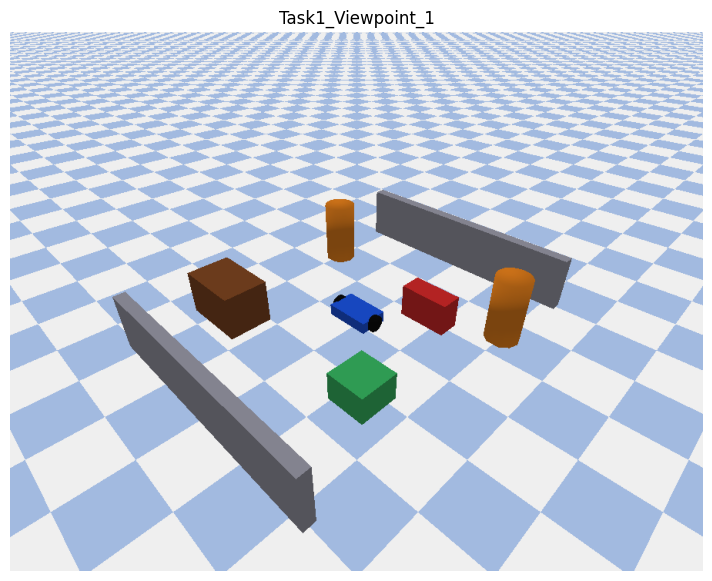

In [17]:
p.resetBasePositionAndOrientation(
    robot_id,
    [0, 0, 0.25],
    p.getQuaternionFromEuler([0, 0, 0])
)

image1 = render_scene(
    camera_distance=8,
    camera_yaw=45,
    camera_pitch=-35,
    target=[0, 0, 0.5],
    filename="Task1_Viewpoint_1"
)

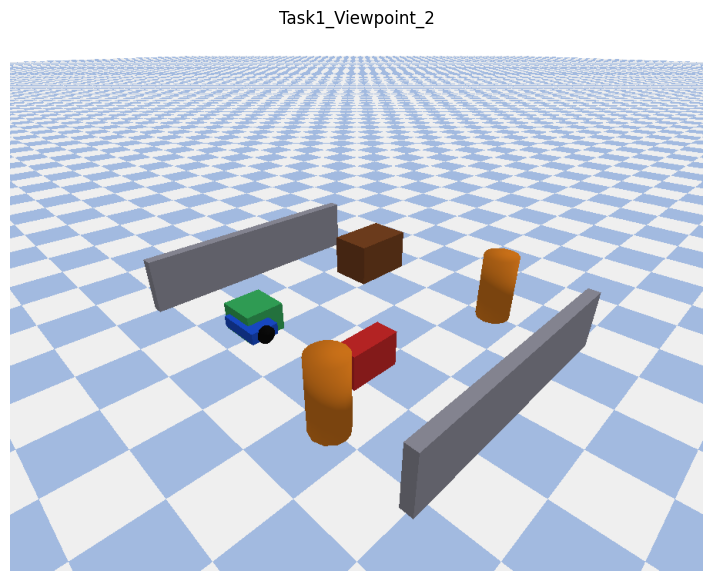

In [18]:
p.resetBasePositionAndOrientation(
    robot_id,
    [1.5, -1.0, 0.25],
    p.getQuaternionFromEuler([0, 0, math.pi/2])
)

image2 = render_scene(
    camera_distance=8,
    camera_yaw=135,
    camera_pitch=-30,
    target=[0, 0, 0.5],
    filename="Task1_Viewpoint_2"
)

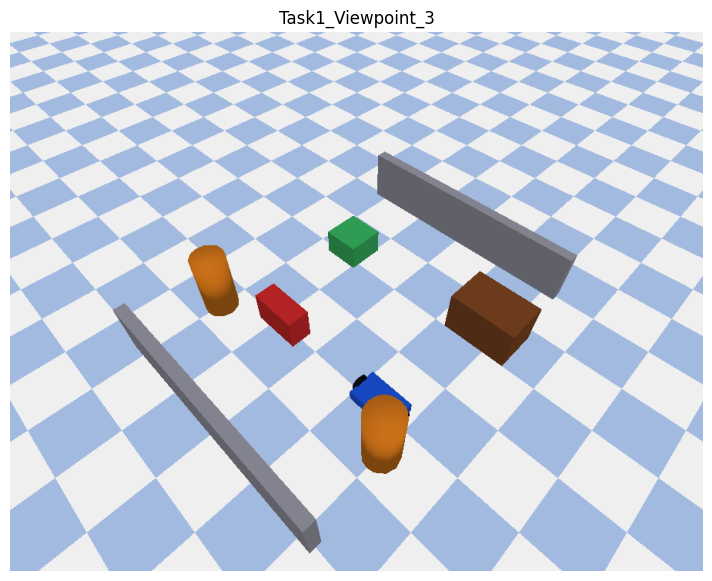

In [19]:
p.resetBasePositionAndOrientation(
    robot_id,
    [-1.5, 1.0, 0.25],
    p.getQuaternionFromEuler([0, 0, math.pi])
)

image3 = render_scene(
    camera_distance=8,
    camera_yaw=225,
    camera_pitch=-50,
    target=[0, 0, 0.5],
    filename="Task1_Viewpoint_3"
)

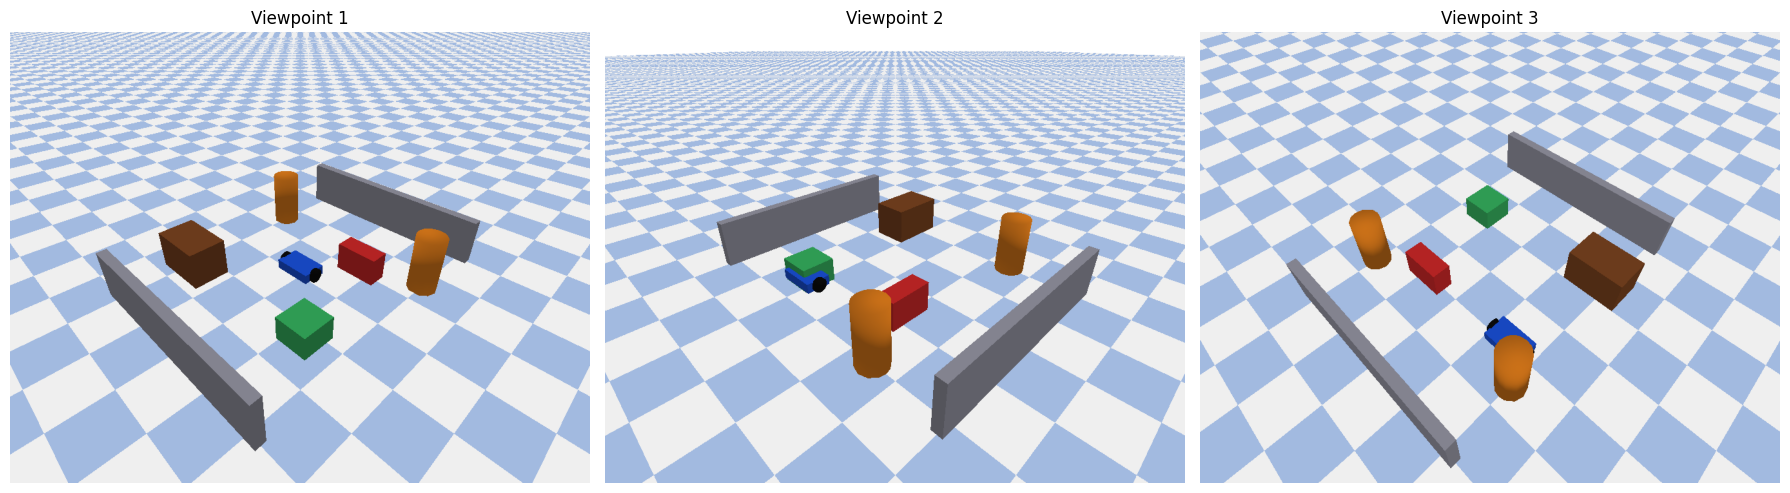

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image1)
axes[0].set_title("Viewpoint 1")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Viewpoint 2")
axes[1].axis("off")

axes[2].imshow(image3)
axes[2].set_title("Viewpoint 3")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
print("========== TASK 1 TEST RESULTS ==========")
print("PyBullet mode: DIRECT")
print("Robot: Two-wheel custom URDF")
print("Custom URDF model types: 5")
print("Environmental object instances:", len(objects))
print("Camera viewpoints captured: 3")
print("Robot positions changed between views: YES")
print("Environmental objects kept fixed: YES")
print("All required images generated: YES")
print("==========================================")

========== TASK 1 TEST RESULTS ==========
PyBullet mode: DIRECT
Robot: Two-wheel custom URDF
Custom URDF model types: 5
Environmental object instances: 7
Camera viewpoints captured: 3
Robot positions changed between views: YES
Environmental objects kept fixed: YES
All required images generated: YES


In [22]:
print("\nEnvironmental object positions:")

for i, obj_id in enumerate(objects, start=1):
    position, orientation = p.getBasePositionAndOrientation(obj_id)
    print(f"Object {i}: {np.round(position, 3)}")


Environmental object positions:
Object 1: [0.  3.  0.5]
Object 2: [ 0.  -3.   0.5]
Object 3: [-2.   1.5  0.6]
Object 4: [2.  1.5 0.6]
Object 5: [-1.8 -1.4  0.4]
Object 6: [ 1.3  -1.2   0.25]
Object 7: [0.8 1.  0.3]
